IMPLEMENTASI MODUL 1 : **LINIER REGRESSION**

1. Gunakan pandas untuk membaca dataset dari file lokal

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('insurance.csv')
print("Menampilkan 5 data teratas")
print(df.head())

x = df['bmi'].values
y = df['charges'].values

x_mean, x_std = np.mean(x), np.std(x)
y_mean, y_std = np.mean(y), np.std(y)

x_scaled = (x - x_mean) / x_std
y_scaled = (y - y_mean) / y_std

Menampilkan 5 data teratas
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


2. Implementasi SGD tanpa scikit-learn

In [26]:
w = 0.0
b = 0.0
learning_rate = 0.01
epochs = 50
n_samples = len(x_scaled)

print("\nMemulai proses pelatihan SGD...")

for epoch in range(epochs):
    indices = np.random.permutation(n_samples)
    x_shuffled = x_scaled[indices]
    y_shuffled = y_scaled[indices]

    for i in range(n_samples):
        xi = x_shuffled[i]
        yi = y_shuffled[i]

        y_pred = w * xi + b
        error = y_pred - yi

        w = w - learning_rate * error * xi
        b = b - learning_rate * error

    if (epoch + 1) % 10 == 0:
        y_pred_all = w * x_scaled + b
        mse = np.mean((y_pred_all - y_scaled)**2)
        print(f"Iterasi {epoch+1}/50 -> Nilai Error MSE = {mse:.4f}")

print("\n-- HASIL AKHIR --")
print("Bobot w =", round(w, 4))
print("Bias b =", round(b, 4))


Memulai proses pelatihan SGD...
Iterasi 10/50 -> Nilai Error MSE = 0.9691
Iterasi 20/50 -> Nilai Error MSE = 0.9905
Iterasi 30/50 -> Nilai Error MSE = 0.9818
Iterasi 40/50 -> Nilai Error MSE = 0.9633
Iterasi 50/50 -> Nilai Error MSE = 0.9711

-- HASIL AKHIR --
Bobot w = 0.1021
Bias b = -0.0341


3. Visualisasikan hasil regresi menggunakan matplotlib

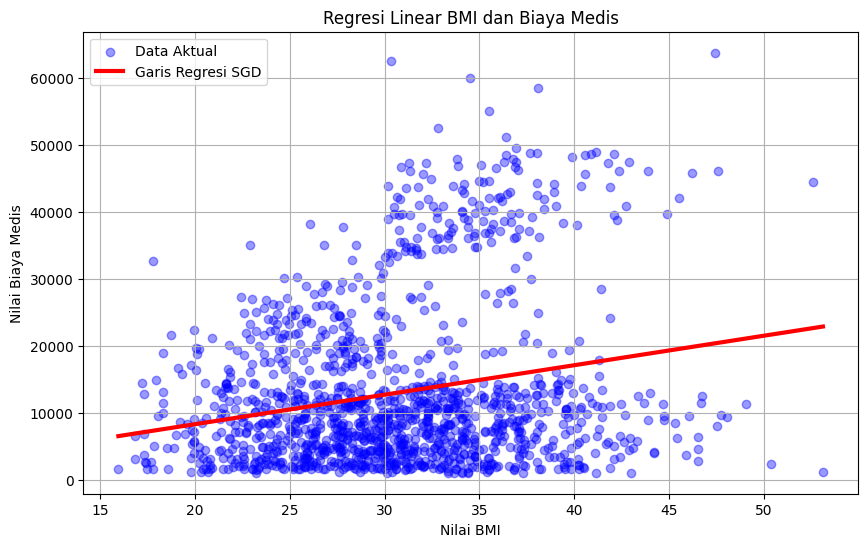

In [15]:
x_line = np.linspace(min(x), max(x), 100)
x_line_scaled = (x_line - x_mean) / x_std
y_line_scaled = w * x_line_scaled + b
y_line = y_line_scaled * y_std + y_mean

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.4, color='blue', label='Data Aktual')
plt.plot(x_line, y_line, color='red', linewidth=3, label='Garis Regresi SGD')
plt.title('Regresi Linear BMI dan Biaya Medis')
plt.xlabel('Nilai BMI')
plt.ylabel('Nilai Biaya Medis')
plt.legend()
plt.grid(True)
plt.show()